In [31]:
#there are some bugs in normalize.  we need to use the first STD and MEAN on test data 

#it has been corrected ,and the SquMean_error decreased

In [32]:
import numpy as np
import pandas as pd

# 设置随机种子
np.random.seed(42)

# 生成200个样本
n_samples = 400

# 生成特征
# 1. 房屋面积 (平方米)
area = np.random.uniform(50, 200, n_samples)

# 2. 卧室数量
bedrooms = np.random.choice([1, 2, 3, 4, 5], n_samples, p=[0.1, 0.3, 0.4, 0.15, 0.05])

# 3. 房龄 (年)
age = np.random.exponential(10, n_samples)
age = np.clip(age, 0, 50)  # 限制在0-50年

# 4. 地理位置评分 (1-10分)
location = np.random.normal(6, 2, n_samples)
location = np.clip(location, 1, 10)

# 生成目标变量：房价 (万元)
# 真实关系：price = 0.8*area + 15*bedrooms - 0.5*age + 8*location + 30 + noise
noise = np.random.normal(0, 20, n_samples)
price = 0.8 * area + 15 * bedrooms - 0.5 * age + 8 * location + 30 + noise

# 创建DataFrame
data = pd.DataFrame({
    'area': area,
    'bedrooms': bedrooms,
    'age': age,
    'location': location,
    'price': price
})


In [33]:
rng=np.random.default_rng(17)

data_train=data.sample(frac=0.67,random_state=rng)
data_test=data.sample(frac=0.33)

In [34]:
data_train.head()

,area,bedrooms,age,location,price
186,172.583330,1,11.660427,6.300838,225.989540
365,107.915396,3,17.035674,7.676982,187.310738
26,79.951067,3,4.251771,5.835698,171.990341
39,116.022874,1,10.003908,9.601881,190.966033
281,100.699274,2,0.936636,9.499153,211.037258


In [35]:
import numpy as np
import pandas as pd


In [36]:
#get ready

In [37]:
#normalize
Mean=data_train.mean(axis=0)
Std=data_train.std(axis=0)
data_normalized=(data_train-Mean)/Std
data_normalized.head()

,area,bedrooms,age,location,price
186,1.123428,-1.748388,0.232495,0.126271,0.238032
365,-0.307932,0.280045,0.803037,0.843644,-0.588638
26,-0.926894,0.280045,-0.553880,-0.116203,-0.916077
39,-0.128481,-1.748388,0.056667,1.847079,-0.510515
281,-0.467653,-0.734172,-0.905757,1.793528,-0.081539


In [38]:
#似乎与标准化也有关系，正常的标准化做的太离谱，s形状，但我这里不要S啊。/max /mean都试了
#正常的标准化0-1之间(x-x.min())/(x.max()-x.min())也不行

In [39]:
rng=np.random.default_rng(17)
primary_parameter={'power1':rng.random((4,7))*0.1,\
                   'threshold1':rng.random(7)*0.1,\
                   'power2':rng.random(7)*0.1,\
                   'threshold2':rng.random(1)*0.1}
print(primary_parameter)

{'power1': array([[0.08450748, 0.01609731, 0.05577445, 0.03680799, 0.0214942 ,
        0.0385824 , 0.04281645],
       [0.06113431, 0.07363859, 0.00152897, 0.02540409, 0.06041459,
        0.00837367, 0.09977637],
       [0.08323461, 0.00367774, 0.05675398, 0.06093401, 0.00069266,
        0.01790839, 0.01649222],
       [0.04619579, 0.05670036, 0.04519092, 0.09197757, 0.08149242,
        0.04011661, 0.02031616]]), 'threshold1': array([0.03583255, 0.0862035 , 0.03488156, 0.09910656, 0.05657688,
       0.02368459, 0.06586973]), 'power2': array([0.06602265, 0.05146076, 0.0279093 , 0.06299182, 0.04791908,
       0.06532888, 0.05422403]), 'threshold2': array([0.01212111])}


In [40]:
def sigmoid(x):
    return 1/(1+np.exp(-x))

In [41]:
def get_loss(y,y_hat):
    return 1/2*pow((y_hat-y),2)

In [42]:
def upgrade_parameter(y,y_hat,x,level_1_to_2,\
              primary_parameter,alph=1):
    
    
    g=y_hat-y
    delta_power2=-alph*g*level_1_to_2
    delta_threshold2=-alph*g

    e=level_1_to_2*(1-level_1_to_2)*primary_parameter['power2']*g    #对后两项，我这里只是一维的输出，power2是1*7的
    delta_power1=-alph*x.reshape(-1,1)@e.reshape(1,-1)    #e,xi都是向量，最后会做成一个4*7的
    delta_threshold1=-alph*(-e)

    primary_parameter['power2']+=delta_power2
    primary_parameter['threshold2']+=delta_threshold2
    primary_parameter['power1']+=delta_power1
    primary_parameter['threshold1']+=delta_threshold1

    return primary_parameter


In [43]:
def standard_BP(data,primary_parameter,turn):
    x=data.iloc[:-1].values
    y=data.iloc[-1]
    
    #input to level1
    level_1=x@primary_parameter['power1'] #向量，直接计算了内积
    #deal and output
    level_1_to_2=sigmoid(level_1-primary_parameter['threshold1'])
    

    #input to level2
    level_2=level_1_to_2@primary_parameter['power2']
    #deal and output
    
    
    y_hat=level_2+primary_parameter['threshold2'][0]    #why ?  #because array([1]) is not array(1)

    if turn%200==0:
        print(get_loss(y,y_hat))
    
    primary_parameter=\
    upgrade_parameter(y,y_hat,x,level_1_to_2,\
                      primary_parameter,alph=0.1)
    
    return primary_parameter    

In [44]:
for j in range(10):
    for i in range(len(data_train)):
        primary_parameter=\
        standard_BP(data_normalized.iloc[i],primary_parameter,i)
print(primary_parameter)
        

0.0010341726851715288
0.04598304822319956
0.04309290448343092
0.02681873807232337
0.0012812245604943836
0.025078097417508587
0.0010138223786688692
0.023721739514206544
0.0009709188280626443
0.02298029330068002
0.0010245366689093517
0.022522561780007586
0.0011700058586405194
0.022132687604689897
0.0014068023153214547
0.021676484398371193
0.0017275104134169548
0.02108061664513339
0.0021034638406110975
0.020323057163331024
{'power1': array([[ 1.14118039,  0.14996361, -0.57295075,  0.56200045,  0.33663058,
         0.48300685,  0.53865974],
       [-0.01839021,  0.12766056, -0.4642675 ,  0.51517306,  0.31452818,
         0.37190338,  0.65100807],
       [ 0.01255272, -0.0688709 ,  0.29985132,  0.02299196, -0.08722534,
        -0.06157823,  0.05668948],
       [ 0.33224407,  0.10695428, -0.4919881 ,  0.30125411,  0.28004602,
         0.28989863,  0.24002469]]), 'threshold1': array([0.39965408, 0.51142482, 0.50084801, 0.61320567, 0.49601318,
       0.48422215, 0.60686194]), 'power2': array([

In [45]:
#the train has finished 
#then is the test

In [46]:
def test_standardBP(data_test,primary_parameter):
    x=data_test.iloc[:-1].values
    y=data_test.iloc[-1]
    
    #input to level1
    level_1=x@primary_parameter['power1'] #向量，直接计算了内积
    #deal and output
    level_1_to_2=sigmoid(level_1-primary_parameter['threshold1'])
   
    #input to level2
    level_2=level_1_to_2@primary_parameter['power2']
    #deal and output
    
   
    y_hat=level_2+primary_parameter['threshold2'][0]

    return y_hat

In [47]:
dataTest_normalized=(data_test-Mean)/Std
dataTest_normalized.head()

,area,bedrooms,age,location,price
57,-0.939148,0.280045,-0.327150,-1.238247,-0.942030
208,-1.573026,0.280045,-0.700290,1.209570,-0.499643
96,0.145694,0.280045,-0.636929,1.770556,0.339515
258,0.302829,0.280045,-0.311333,-1.054880,0.023416
229,0.505612,-0.734172,0.868878,2.054616,0.341808


In [48]:
dataTest_preduction=dataTest_normalized.apply(test_standardBP,axis=1,args=(primary_parameter,))
dataTest_preduction.head()

57    -0.961529
208   -0.485883
96     1.119998
258    0.044813
229    1.006352
dtype: float64

In [49]:
price_preduction=dataTest_preduction*Std.iloc[-1]+Mean.iloc[-1]

In [50]:
price_preduction.name='price_preduction'
price_preduction.head()

57     169.863670
208    192.118520
96     267.255564
258    216.949077
229    261.938205
Name: price_preduction, dtype: float64

In [51]:
result=pd.concat([data_test,price_preduction],axis=1)
result.head()

,area,bedrooms,age,location,price,price_preduction
57,79.397429,3,6.387858,3.683271,170.776031,169.863670
208,50.759238,3,2.872395,8.378941,191.474722,192.118520
96,128.409924,3,3.469336,9.455086,230.737778,267.255564
258,135.509176,3,6.536873,4.035025,215.947937,216.949077
229,144.670794,2,17.655975,10.000000,230.845068,261.938205


In [52]:
import matplotlib.pyplot as plt
%matplotlib inline

<Axes: xlabel='price', ylabel='price_preduction'>

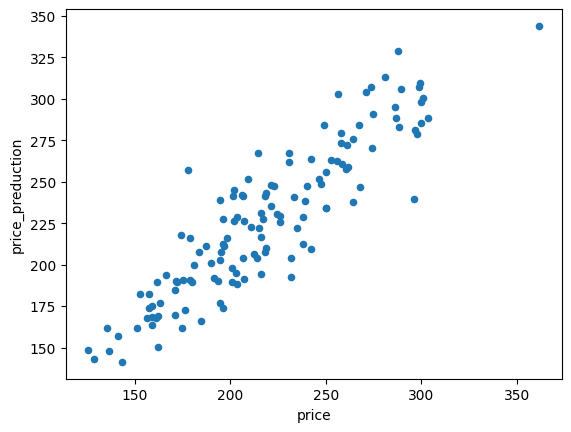

In [55]:
result.plot(kind='scatter',x='price',y='price_preduction')  #wait to add y=x

In [54]:
MeanSqu_error=pow(result['price']-result['price_preduction'],2).mean()
print(f'Mean Squared Error:{MeanSqu_error}')
print(f'Root Mean Squared Error:{pow(MeanSqu_error,0.5)}')

Mean Squared Error:490.5341267020089
Root Mean Squared Error:22.14800502758677
